In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import os
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [2]:
CURRENT_DIRECTORY =  os.getcwd()
SRC_DIRECTORY = Path(CURRENT_DIRECTORY).parents[1]
print(SRC_DIRECTORY)

BASE_DATASET_PATH = Path(SRC_DIRECTORY)
BASE_DATASET_PATH = BASE_DATASET_PATH / "datasets"
print(BASE_DATASET_PATH)

/Users/yitong/Desktop/Uni_Skool/Y3 Internship SingHealth/code/Mobile-AED-Study
/Users/yitong/Desktop/Uni_Skool/Y3 Internship SingHealth/code/Mobile-AED-Study/datasets


In [3]:
read_from_filepath = Path(BASE_DATASET_PATH / f"singapore_data/cleaned_data/combined_demographic_geo_2010_2018.csv")
interpolated_demographic_2010_2018 = pd.read_csv(read_from_filepath)

read_from_filepath = Path(BASE_DATASET_PATH / f"singapore_data/cleaned_data/combined_demographic_geo_2019_2021.csv")
interpolated_demographic_2019_2021 = pd.read_csv(read_from_filepath)

In [18]:
combined_demographic = pd.concat([interpolated_demographic_2010_2018,
                                  interpolated_demographic_2019_2021], ignore_index=True)
combined_demographic = combined_demographic.drop(columns = ["Unnamed: 0"])
# remove inf values, set them to 0
combined_demographic = combined_demographic.replace([np.inf, -np.inf], 0)
combined_demographic.head()

,subzone_n,pln_area_n,Year,total,above_60,above_60_proportion,male_chinese_proportion,female_chinese_proportion,male_malays_proportion,female_malays_proportion,male_indians_proportion,female_indians_proportion,male_others_proportion,female_others_proportion,business_1_encoding,business_2_encoding,business_park_encoding,school_encoding,airport,is_residential
0,admiralty,sembawang,2010,11412,974,85.348756,357.167893,362.337890,74.044865,74.483000,46.442341,44.602173,20.855240,18.226428,0,0,0,1,0,1
1,admiralty,sembawang,2011,11744,1071,91.195504,354.138283,359.587875,76.549728,77.826975,46.151226,44.618529,20.265668,18.136921,0,0,0,1,0,1
2,admiralty,sembawang,2012,12104,1154,95.340383,351.536682,357.319894,78.734303,80.717118,45.769993,44.778586,19.745539,18.175810,0,0,0,1,0,1
3,admiralty,sembawang,2013,12438,1238,99.533687,349.734684,355.603795,81.041968,83.695128,45.505708,44.782119,19.376105,18.330921,0,0,0,1,0,1
4,admiralty,sembawang,2014,12777,1326,103.780230,347.655944,353.760664,83.274634,86.561791,45.237536,44.767942,18.783752,18.470690,0,0,0,1,0,1


In [5]:
# def plot_min_max(input_table, column_name):
#     ## plotting min and max for each year 
#     summary_stats = input_table.groupby('Year')[column_name].agg(['min', 'max']).reset_index()

#     # 2. Plotting
#     plt.figure(figsize=(12, 6))

#     # Define the x-axis (years)
#     years = summary_stats['Year']
#     x = range(len(years))
#     width = 0.35  # Width of the bars

#     # Create the bars
#     plt.bar([i - width/2 for i in x], summary_stats['min'], width, label='Minimum', color='#1f77b4')
#     plt.bar([i + width/2 for i in x], summary_stats['max'], width, label='Maximum', color='#d62728')

#     # Formatting
#     plt.title(f'Minimum and Maximum {column_name} per Year (2010–2021)', fontsize=14)
#     plt.xlabel('Year', fontsize=12)
#     plt.ylabel(f'{column_name} per 1000 residents', fontsize=12)
#     plt.xticks(x, years)
#     plt.legend()
#     plt.grid(axis='y', linestyle='--', alpha=0.7)

#     # Add value labels on top of the bars
#     for i in x:
#         plt.text(i - width/2, summary_stats['min'][i] + 0.1, f"{summary_stats['min'][i]:.2f}", ha='center', fontsize=9)
#         plt.text(i + width/2, summary_stats['max'][i] + 0.1, f"{summary_stats['max'][i]:.2f}", ha='center', fontsize=9)

#     plt.tight_layout()
#     plt.show()

In [6]:
def plot_min_max(input_table, columns_list):
    # Dynamically set grid dimensions
    # If there's only one column, use 1 column; otherwise, use 2.
    n_cols = 1 if len(columns_list) == 1 else 2
    n_rows = math.ceil(len(columns_list) / n_cols)
    
    # Adjust figsize: if 1 column, make it narrower (e.g., width 10)
    fig_width = 16
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_width, 6 * n_rows), squeeze=False)
    axes = axes.flatten()  # Flatten to easily iterate
    
    # Loop through each column and create a subplot
    for i, col in enumerate(columns_list):
        ax = axes[i]
        
        # Aggregate data
        stats = input_table.groupby('Year')[col].agg(['min', 'max']).reset_index()
        
        years = stats['Year']
        x = range(len(years))
        width = 0.35
        
        # Plot bars
        ax.bar([p - width/2 for p in x], stats['min'], width, label='Min', color='#1f77b4')
        ax.bar([p + width/2 for p in x], stats['max'], width, label='Max', color='#d62728')
        
        # Formatting individual subplot
        clean_title = col.replace('_', ' ').title()
        ax.set_title(clean_title, fontsize=12, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(years, rotation=45)
        ax.set_ylabel('Proportion')
        ax.grid(axis='y', linestyle='--', alpha=0.3)
        
        # Value labels
        for j in x:
            ax.text(j - width/2, stats['min'][j], f"{stats['min'][j]:.2f}", 
                    ha='center', va='bottom', fontsize=8)
            ax.text(j + width/2, stats['max'][j], f"{stats['max'][j]:.2f}", 
                    ha='center', va='bottom', fontsize=8)

    # Clean up empty subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
        
    plt.suptitle('Min and Max Proportions per 1000 residents (2010–2021)', fontsize=20, y=1.02)
    plt.tight_layout()
    plt.show()

In [ ]:
# def plot_average(input_table, column_name):
#     # Aggregate the mean for each year
#     # We use 'mean' to find the average of the specified column
#     summary_stats = input_table.groupby('Year')[column_name].mean().reset_index()

#     # Plotting
#     plt.figure(figsize=(10, 6))

#     # Define the x-axis and the average values
#     years = summary_stats['Year']
#     averages = summary_stats[column_name]
#     x = range(len(years))

#     # Create the bar chart for the average
#     bars = plt.bar(x, averages, color='#2ca02c', edgecolor='black', alpha=0.8)

#     # Formatting
#     plt.title(f'Average {column_name.replace("_", " ").title()} per Year (2010–2021)', fontsize=14, fontweight='bold')
#     plt.xlabel('Year', fontsize=12)
#     plt.ylabel(f'Average {column_name.replace("_", " ").title()} per 1000 residents', fontsize=12)
#     plt.xticks(x, years)
#     plt.grid(axis='y', linestyle='--', alpha=0.6)

#     # Add value labels on top of each bar
#     for bar in bars:
#         height = bar.get_height()
#         plt.text(bar.get_x() + bar.get_width() / 2, height + (height * 0.01), 
#                  f"{height:.2f}", ha='center', va='bottom', fontsize=10, fontweight='bold')

#     plt.tight_layout()
#     plt.show()

In [23]:
def plot_average(input_table, columns_list):
    # 1. Dynamically set grid dimensions
    n_cols = 1 if len(columns_list) == 1 else 2
    n_rows = math.ceil(len(columns_list) / n_cols)
    
    # Adjust fig_width based on number of columns
    fig_width = 16
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_width, 6 * n_rows), squeeze=False)
    axes = axes.flatten()
    
    # 2. Loop through each column and create a subplot
    for i, col in enumerate(columns_list):
        ax = axes[i]
        
        # Aggregate the mean for each year
        summary_stats = input_table.groupby('Year')[col].mean().reset_index()
        
        years = summary_stats['Year']
        averages = summary_stats[col]
        x = range(len(years))
        
        # Create the bar chart for the average
        bars = ax.bar(x, averages, color='#2ca02c', edgecolor='black', alpha=0.8)
        
        # Formatting individual subplot
        clean_title = col.replace('_', ' ').title()
        ax.set_title(f'Average {clean_title}', fontsize=12, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(years, rotation=45)
        ax.set_ylabel('Avg per 1000 residents')
        ax.grid(axis='y', linestyle='--', alpha=0.3)
        
        # Add value labels on top of each bar
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, height, 
                    f"{height:.2f}", ha='center', va='bottom', 
                    fontsize=9, fontweight='bold')

    # 3. Clean up empty subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
        
    plt.suptitle('Average Proportions per 1000 residents (2010–2021)', fontsize=20, y=1.02)
    plt.tight_layout()
    plt.show()

In [ ]:
# def plot_iqr_box(input_table, column_name):
#     plt.figure(figsize=(12, 6))
    
#     # Create the box plot
#     # The box represents the IQR, the line inside is the median
#     sns.boxplot(data=input_table, x='Year', y=column_name)
    
#     # Formatting
#     plt.title(f'Distribution and IQR of {column_name.replace("_", " ").title()} by Year', fontsize=15)
#     plt.xlabel('Year', fontsize=12)
#     plt.ylabel(column_name.replace("_", " ").title(), fontsize=12)
#     plt.grid(axis='y', linestyle='--', alpha=0.5)
    
#     plt.tight_layout()
#     plt.show()

In [38]:
def plot_iqr(input_table, columns_list):
    # Dynamically set grid dimensions
    n_cols = 1 if len(columns_list) == 1 else 2
    n_rows = math.ceil(len(columns_list) / n_cols)
    
    # Adjust fig_width: if 1 column, make it narrower; if 2, keep it wide
    fig_width = 10 if n_cols == 1 else 16
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_width, 6 * n_rows), squeeze=False)
    axes = axes.flatten()
    
    # Loop through each column and create a boxplot
    for i, col in enumerate(columns_list):
        ax = axes[i]
        
        # Create the box plot using Seaborn
        # The box represents the IQR (25th to 75th percentile)
        sns.boxplot(data=input_table, x='Year', y=col, ax=ax)
        
        # Formatting individual subplot
        clean_title = col.replace('_', ' ').title()
        ax.set_title(f'Distribution & IQR: {clean_title}', fontsize=12, fontweight='bold')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
        ax.set_ylabel('Proportion / Value')
        ax.set_xlabel('Year')
        ax.grid(axis='y', linestyle='--', alpha=0.3)

    # Clean up empty subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
        
    plt.suptitle('Interquartile Range (IQR) and Distribution by Group (2010–2021)', fontsize=20, y=1.02)
    plt.tight_layout()
    plt.show()


#### Plotting for above 60 proportion

#### Plotting min max values

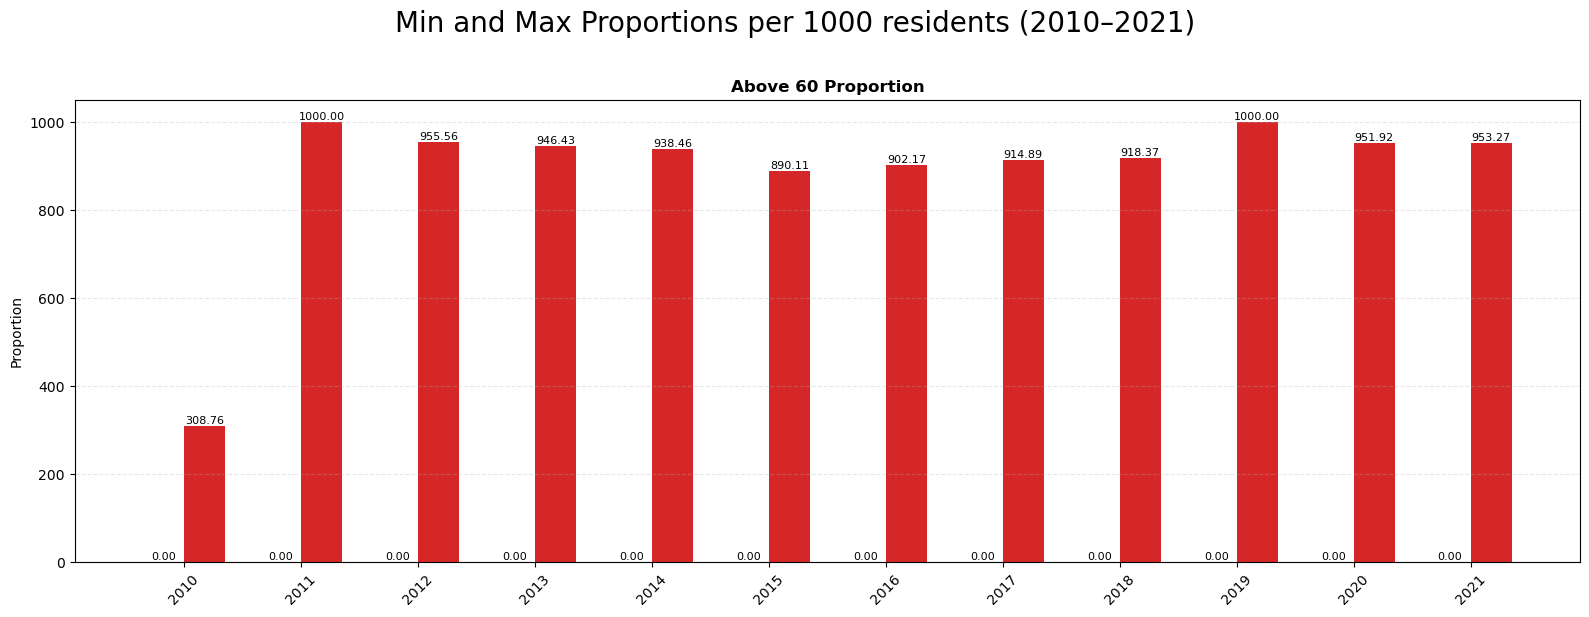

In [9]:
plot_min_max(combined_demographic, ['above_60_proportion'])


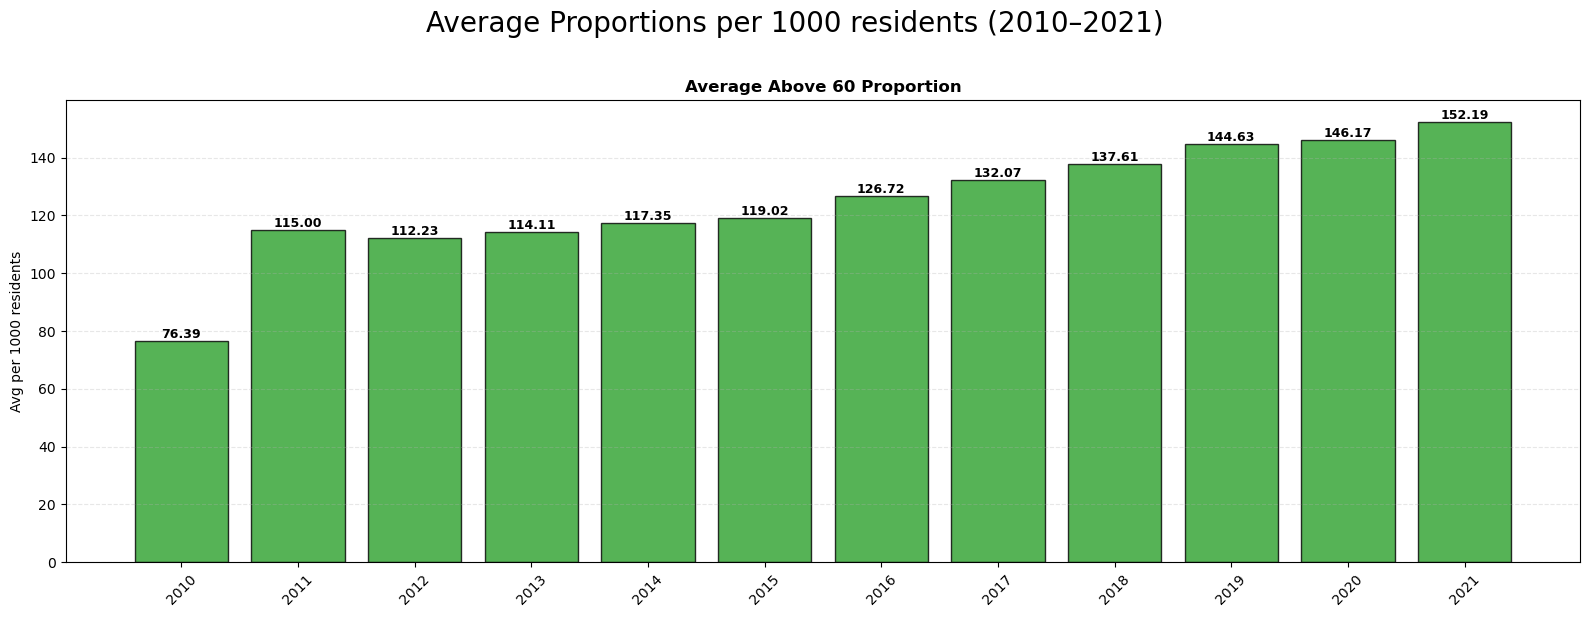

In [24]:
plot_average(combined_demographic, ['above_60_proportion'])

/var/folders/b8/1t_kfq0s27zbtp79vq8klgfm0000gn/T/ipykernel_31879/1096306121.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


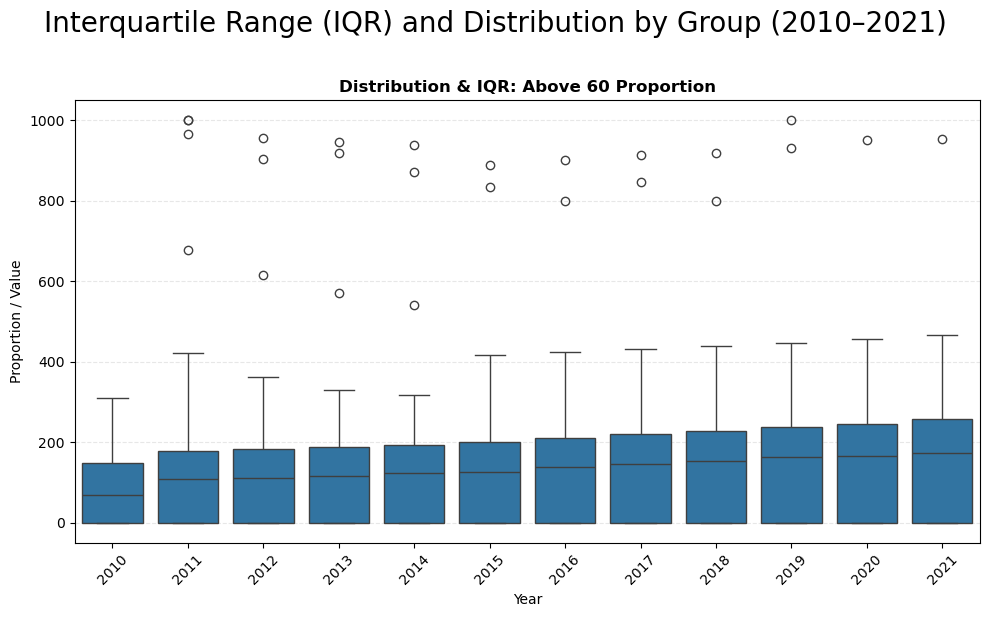

In [39]:
plot_iqr(combined_demographic, ['above_60_proportion'])

In [29]:
ethnicity_columns_of_interest = [
    'male_chinese_proportion', 'female_chinese_proportion', 
    'male_malays_proportion', 'female_malays_proportion', 
    'male_indians_proportion', 'female_indians_proportion', 
    'male_others_proportion', 'female_others_proportion'
]

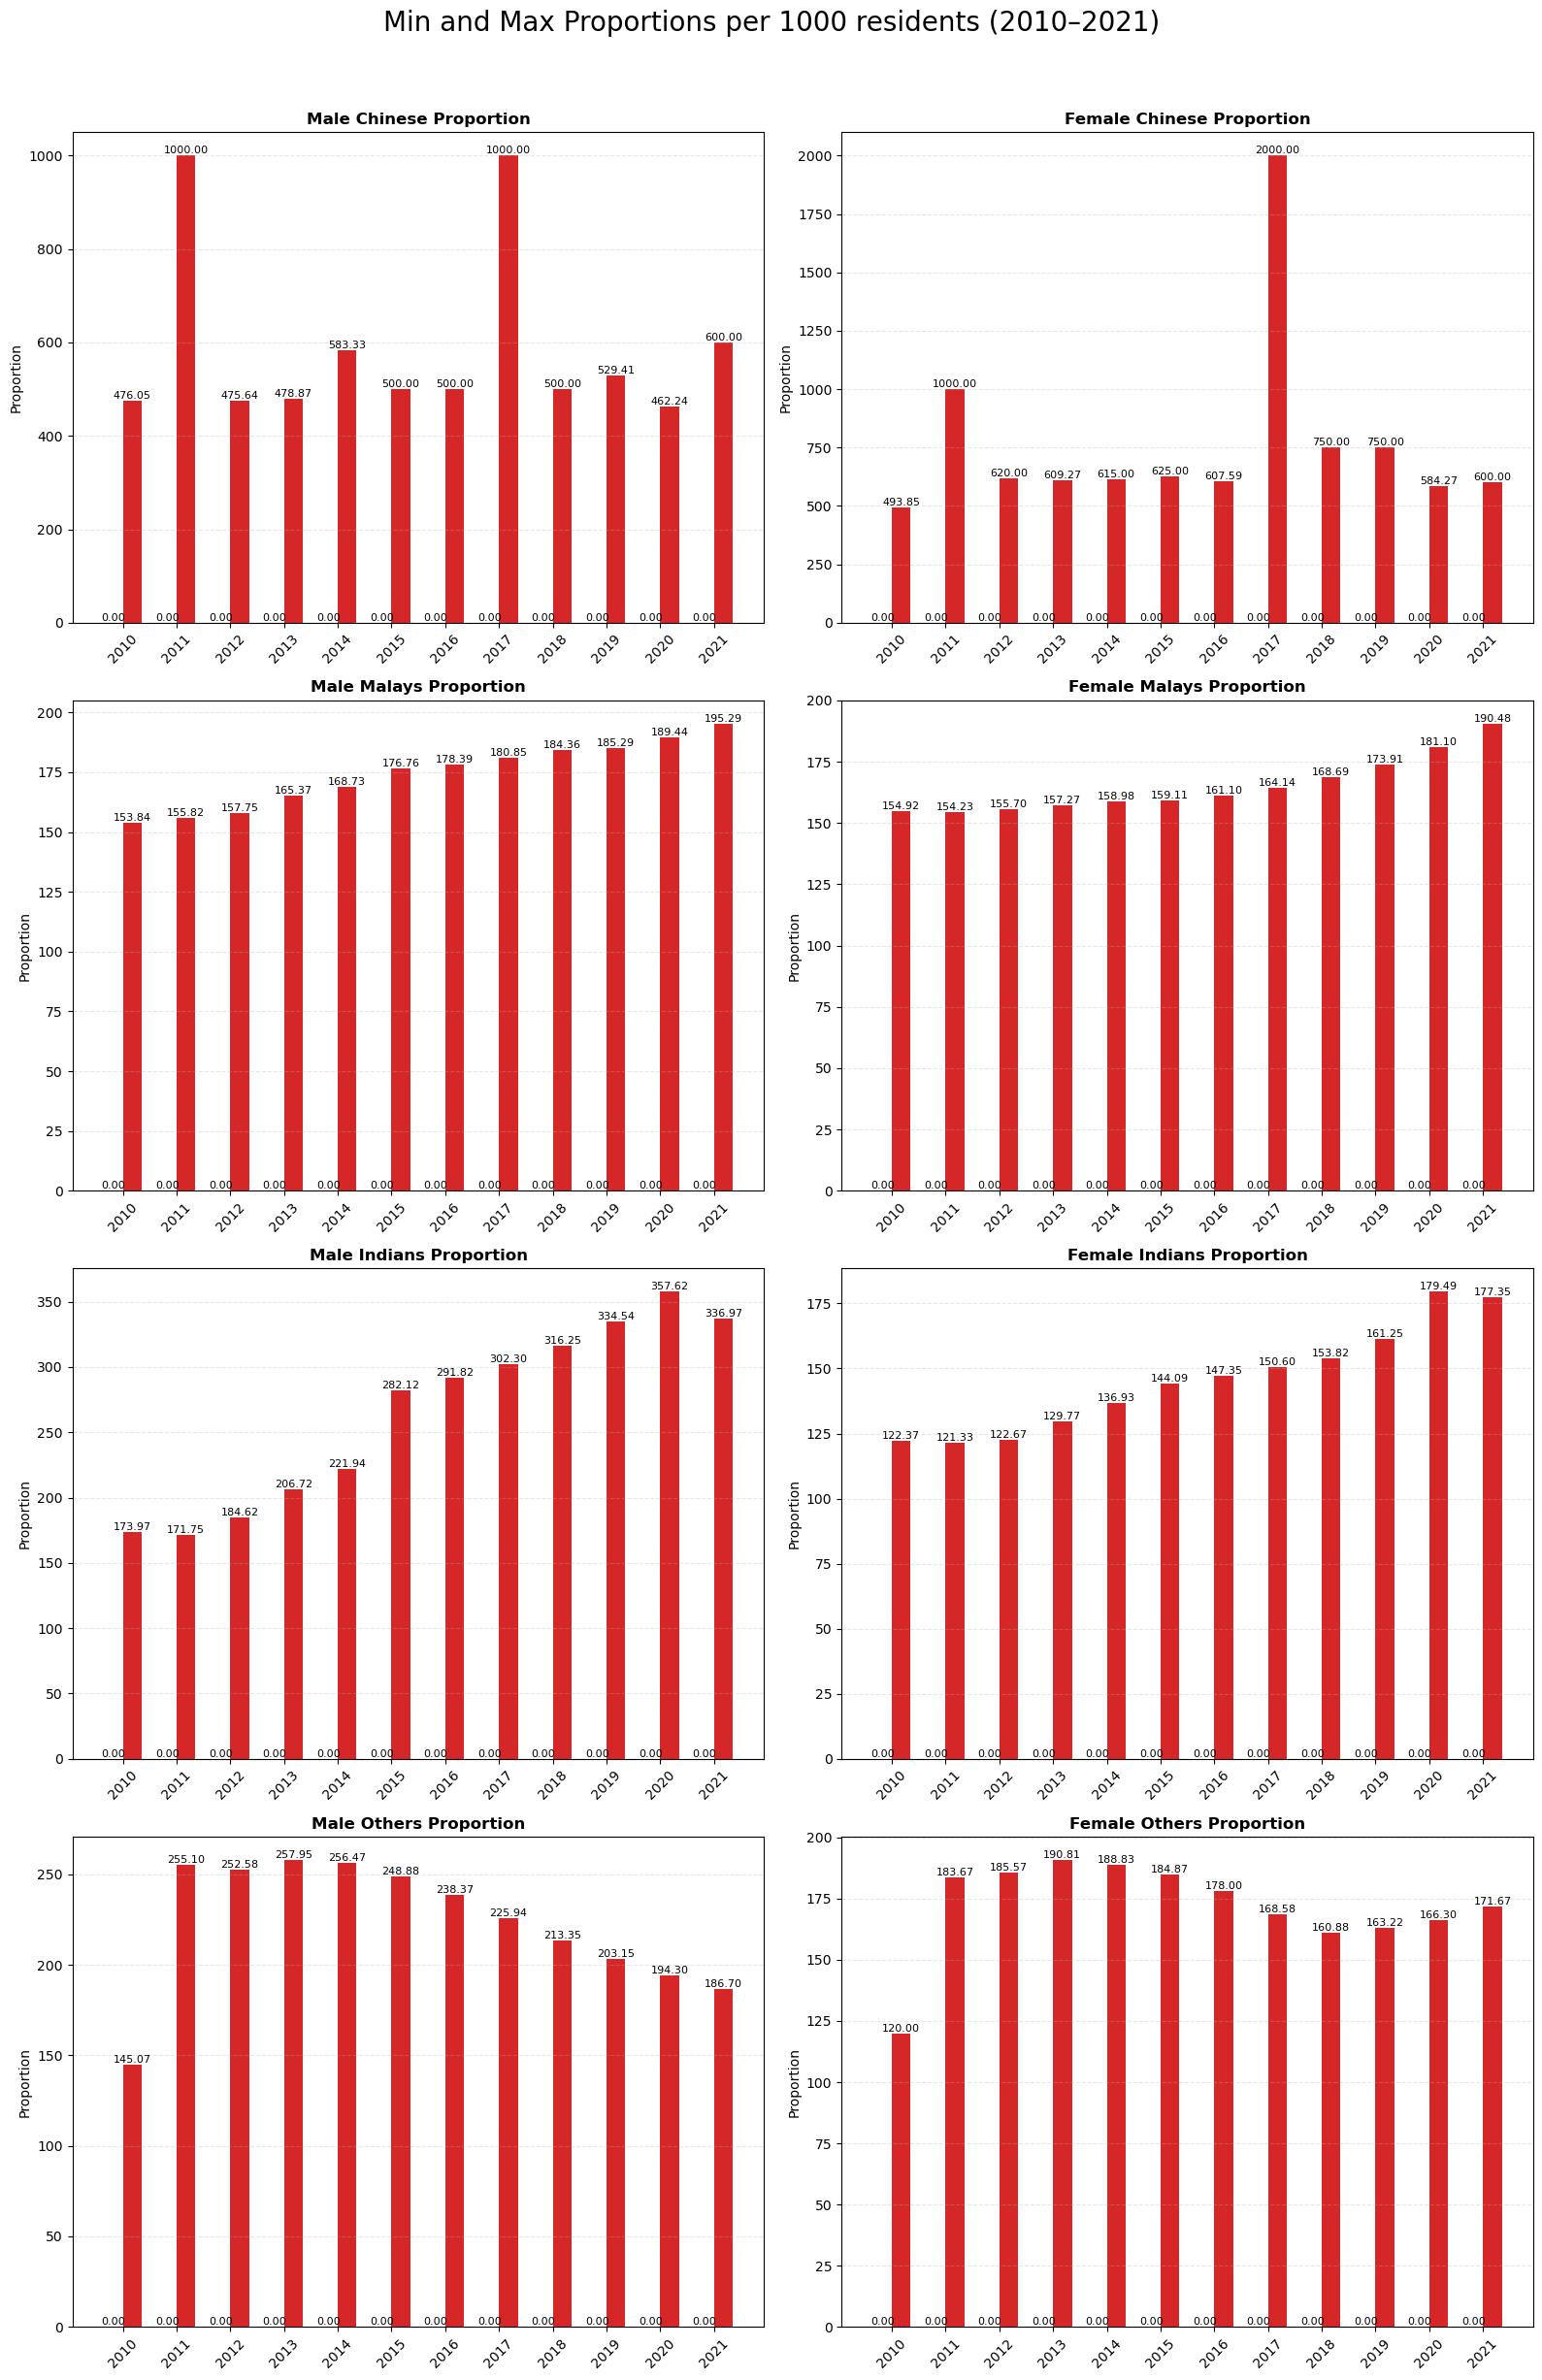

In [30]:
plot_min_max(combined_demographic, ethnicity_columns_of_interest)

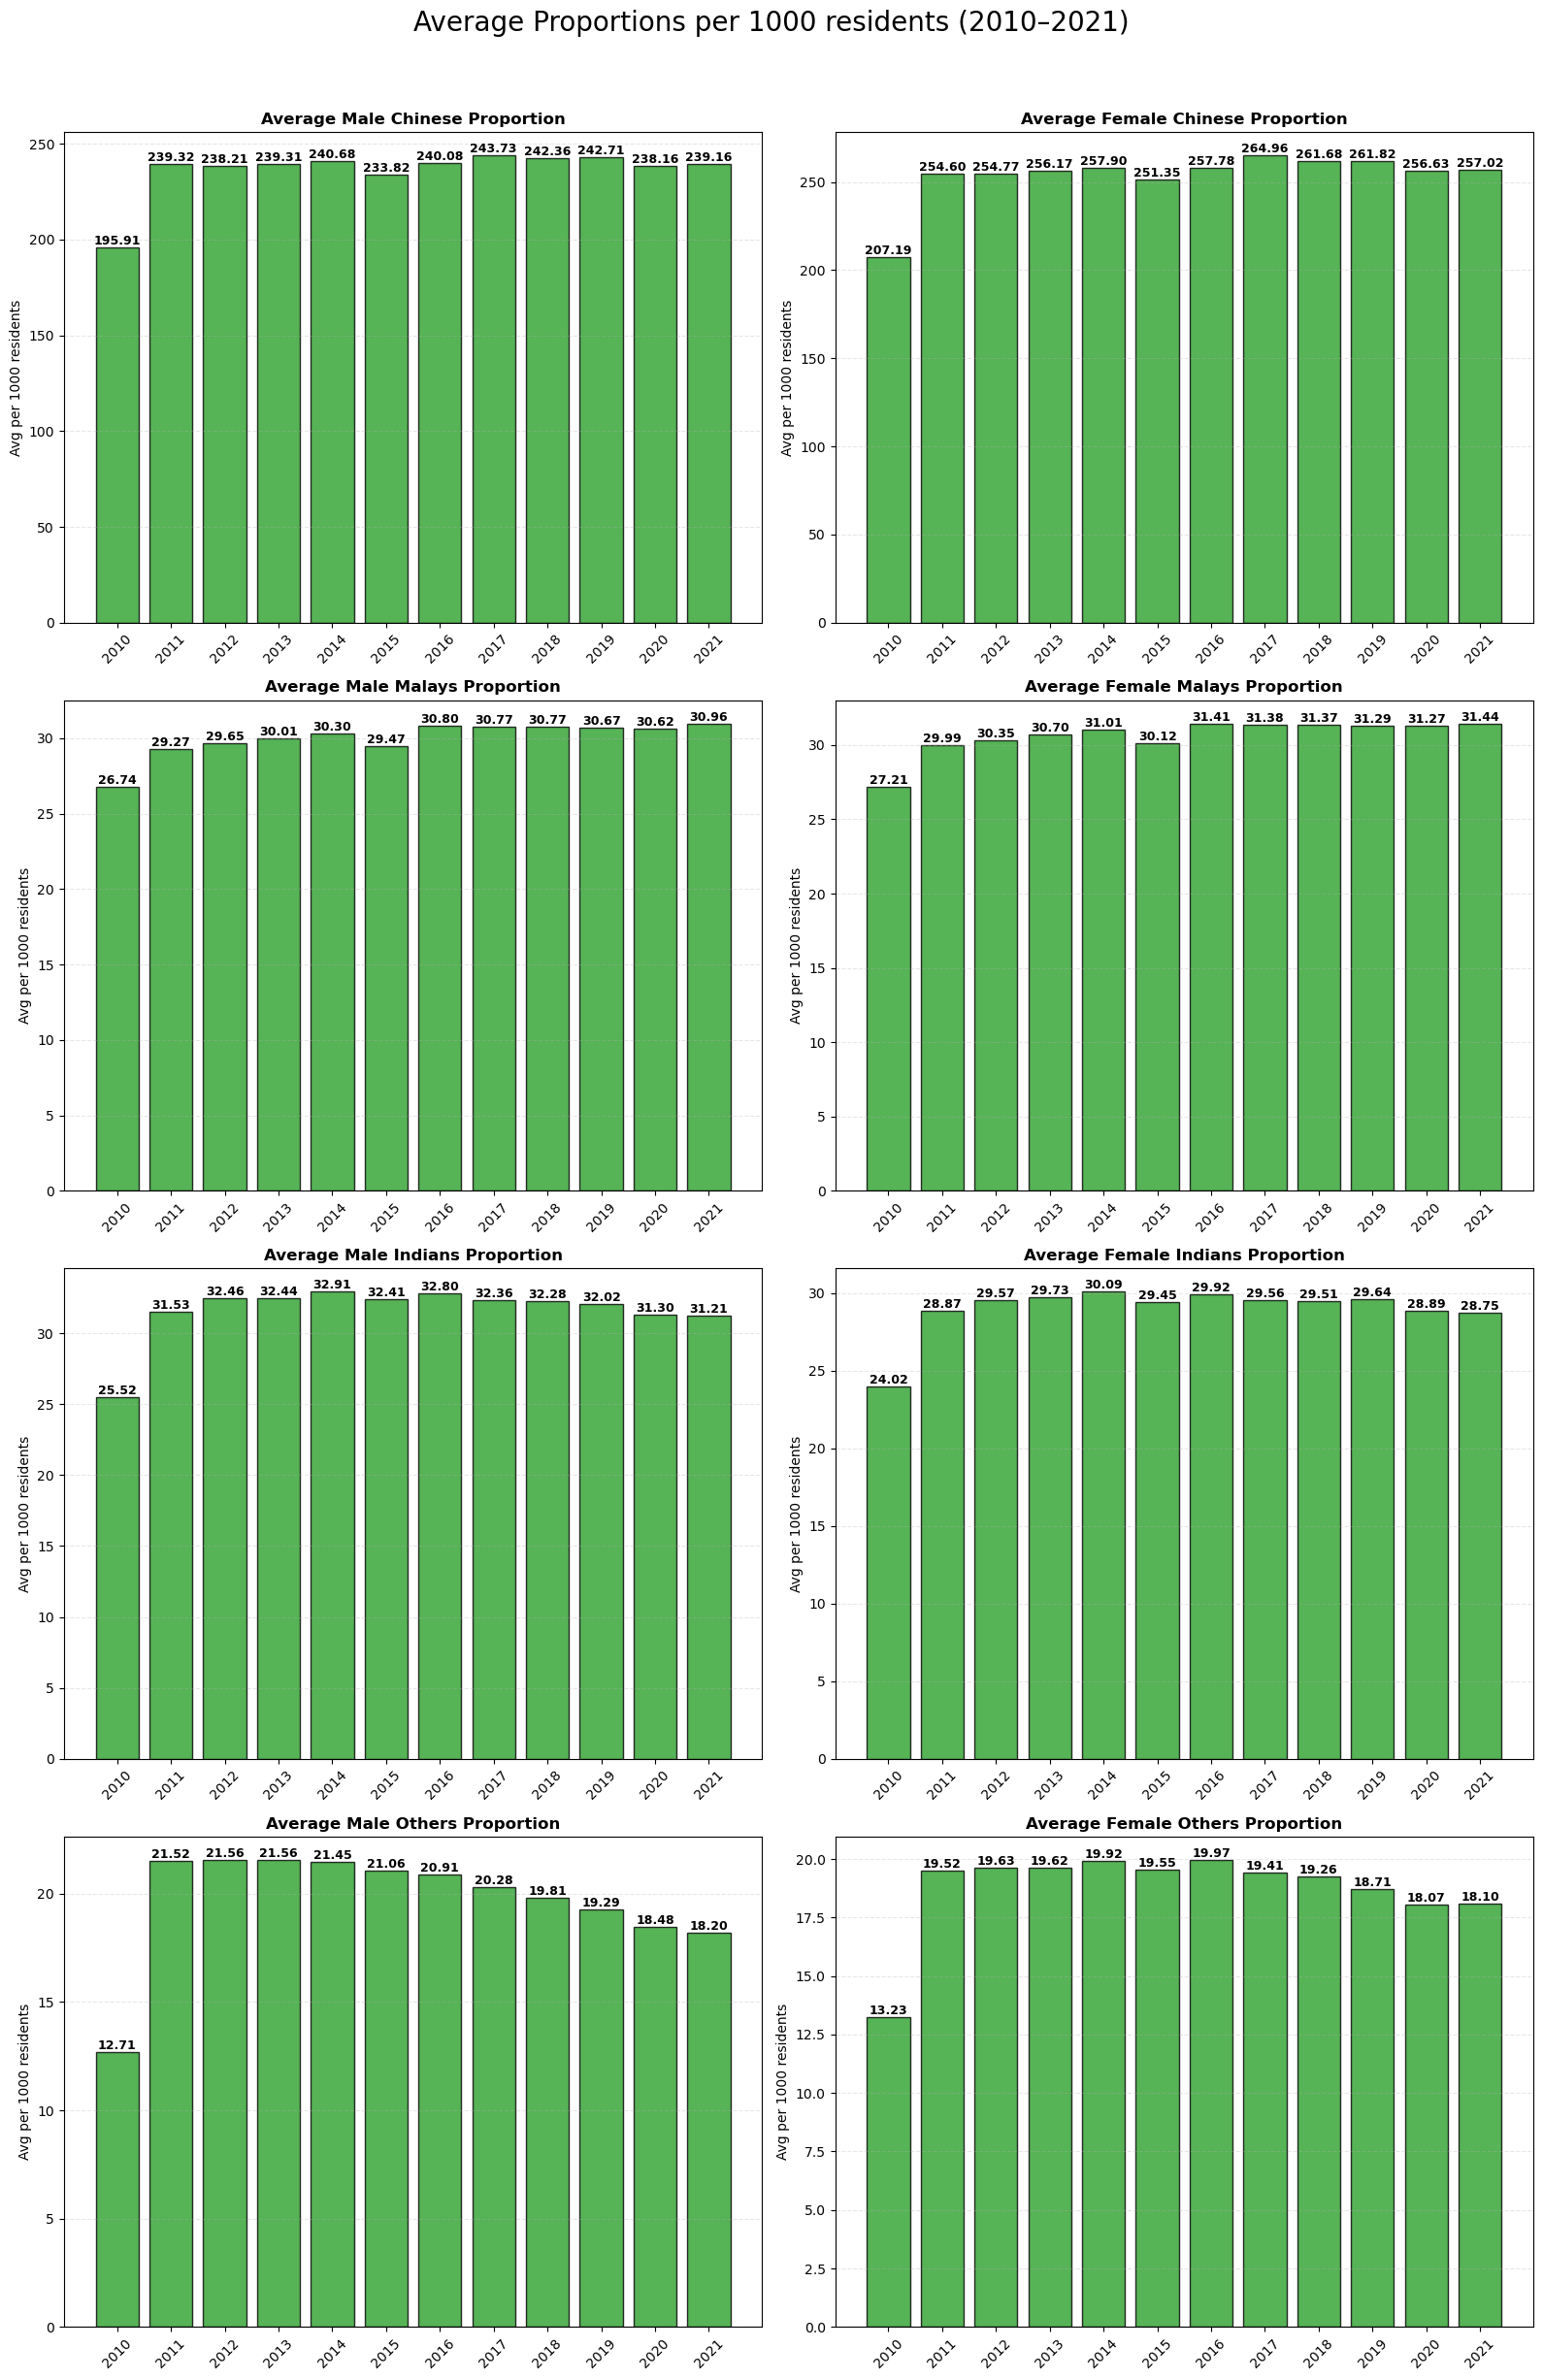

In [31]:
plot_average(combined_demographic, ethnicity_columns_of_interest)

Female chinese proportion for 2017 had one that was 2000. Based on the interpolated numbers, there were 2 chinese females and 1 chinese male in the murai subzone. The small numbers of residents, resulting in this outlier. The ethnicity proportions for murai will be set to 0 for all years. This was handled in map_ohca_counts_to_subzone.ipynb

/var/folders/b8/1t_kfq0s27zbtp79vq8klgfm0000gn/T/ipykernel_31879/1096306121.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
/var/folders/b8/1t_kfq0s27zbtp79vq8klgfm0000gn/T/ipykernel_31879/1096306121.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
/var/folders/b8/1t_kfq0s27zbtp79vq8klgfm0000gn/T/ipykernel_31879/1096306121.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
/var/folders/b8/1t_kfq0s27zbtp79vq8klgfm0000gn/T/ipykernel_31879/1096306121.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a Fi

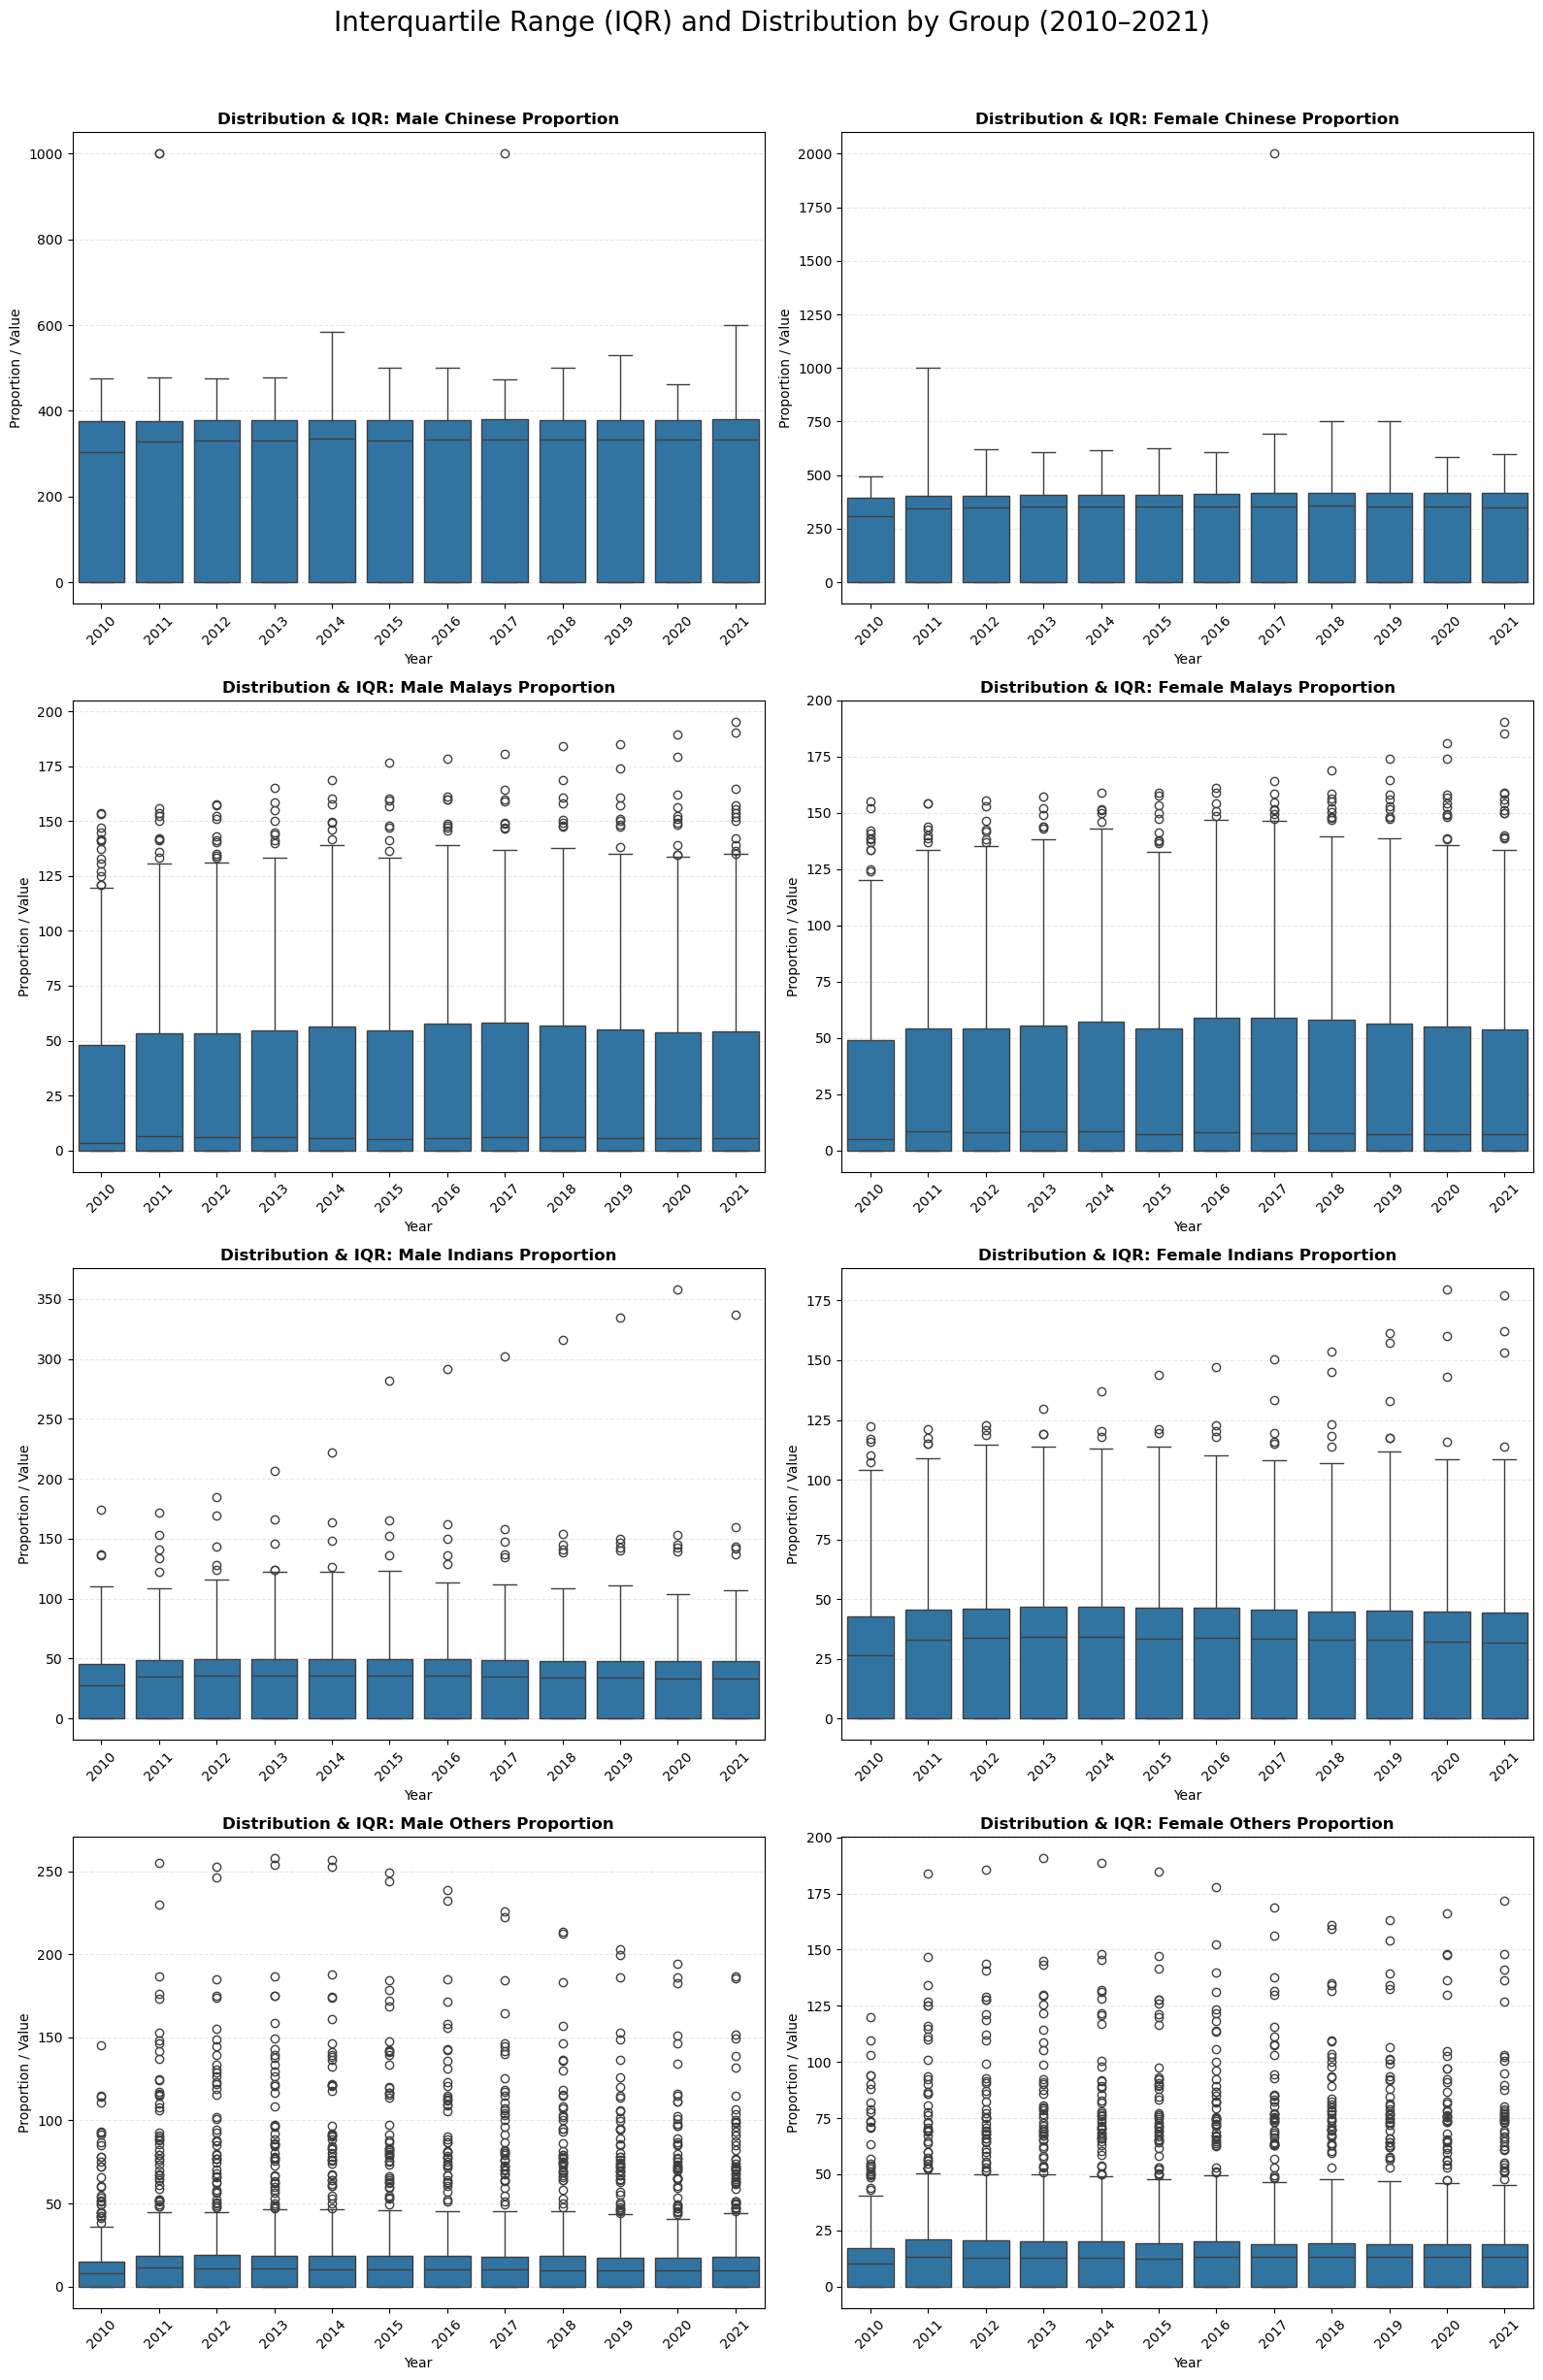

In [40]:
plot_iqr(combined_demographic, ethnicity_columns_of_interest)